Parte 1: Cargar archivos

In [15]:
import numpy as np
import pandas as pd

# Embeddings
visual_embeddings = np.load(
    "data/processed/visual_embeddings.npy"
)

text_embeddings = np.load(
    "data/processed/movie_text_embeddings.npy"
)

# Metadatos
visual_meta = pd.read_csv(
    "data/processed/movies_visual_metadata.csv"
)

text_meta = pd.read_csv(
    "data/processed/movie_embeddings_metadata.csv"
)

print("Visual embeddings:", visual_embeddings.shape)
print("Text embeddings:", text_embeddings.shape)

print("Visual metadata:", visual_meta.shape)
print("Text metadata:", text_meta.shape)

Visual embeddings: (150, 2048)
Text embeddings: (137, 768)
Visual metadata: (150, 8)
Text metadata: (137, 4)


Parte 2: Crear tabla de correspondencia

In [16]:
# Crear títulos normalizados

visual_meta["title_clean"] = (
    visual_meta["title"]
    .astype(str)
    .str.strip()
    .str.lower()
)

text_meta["title_clean"] = (
    text_meta["title"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Guardar índices originales
visual_meta = visual_meta.reset_index()
text_meta = text_meta.reset_index()

# Buscar coincidencias
merged = visual_meta.merge(
    text_meta,
    on="title_clean",
    suffixes=("_visual", "_text")
)

print("Películas comunes encontradas:", len(merged))

merged[
    [
        "index_visual",
        "title_visual",
        "index_text",
        "title_text"
    ]
].head(10)

Películas comunes encontradas: 23


,index_visual,title_visual,index_text,title_text
0,6,Proyecto Salvación,0,Proyecto Salvación
1,8,Matrix,1,Matrix
2,17,Avatar: Fuego y ceniza,2,Avatar: Fuego y ceniza
3,22,El diablo viste de Prada,3,El diablo viste de Prada
4,24,Nymphomaniac. Volumen 2,4,Nymphomaniac. Volumen 2
5,43,Zootrópolis 2,5,Zootrópolis 2
6,46,Acero puro,6,Acero puro
7,47,Cadena perpetua,7,Cadena perpetua
8,86,Vengadores: Infinity War,8,Vengadores: Infinity War
9,88,La guerra de los mundos,9,La guerra de los mundos


Parte 3: Reordenar embeddings

In [17]:
visual_common = visual_embeddings[
    merged["index_visual"].values
]

text_common = text_embeddings[
    merged["index_text"].values
]

print("Visual común:", visual_common.shape)
print("Text común:", text_common.shape)

Visual común: (23, 2048)
Text común: (23, 768)


Parte 4: Verificación de títulos

In [18]:
titles = merged["title_visual"].tolist()

print("Primeras películas integradas:\n")

for i in range(min(10, len(titles))):
    print(f"{i+1}. {titles[i]}")

Primeras películas integradas:

1. Proyecto Salvación
2. Matrix
3. Avatar: Fuego y ceniza
4. El diablo viste de Prada
5. Nymphomaniac. Volumen 2
6. Zootrópolis 2
7. Acero puro
8. Cadena perpetua
9. Vengadores: Infinity War
10. La guerra de los mundos


## Fundamentos Teóricos: Integración Multimodal Trimodal

En esta sección fusionamos los conocimientos extraídos de múltiples modalidades:
1. **Visión (Pósters):** ResNet-50 (2048 dimensiones).
2. **Texto (Reseñas):** DistilBERT (768 dimensiones).

### Estrategia de Fusión
Implementamos una **fusión temprana a nivel de características (Late-to-Early Fusion)** concatenando los vectores normalizados (L2) de ambas modalidades. La normalización es crucial para evitar que el espacio de 2048 dimensiones de ResNet domine la métrica del coseno sobre el de 768 dimensiones de DistilBERT.

### Métricas de Evaluación Cuantitativa
1. **Precisión@K:** Medida de cuántas recomendaciones en el top $K$ son relevantes para el usuario.
2. **NDCG@K:** Considera el orden (ranking) de las recomendaciones, penalizando fuertemente los aciertos que aparecen en las posiciones inferiores.
3. **Silhouette Score:** Evaluaremos la calidad del agrupamiento de los embeddings en el espacio t-SNE, verificando si las películas de géneros similares se agrupan en clusters densos y separados.


Parte 5: Integración multimodal

In [19]:
from sklearn.preprocessing import normalize

visual_norm = normalize(visual_common)
text_norm = normalize(text_common)

combined_embeddings = np.concatenate(
    [visual_norm, text_norm],
    axis=1
)

print("Embeddings multimodales:")
print(combined_embeddings.shape)

Embeddings multimodales:
(23, 2816)


Parte 6: Guardar resultado

In [20]:
np.save(
    "data/processed/multimodal_embeddings.npy",
    combined_embeddings
)

merged.to_csv(
    "data/processed/multimodal_metadata.csv",
    index=False
)

print("Embeddings multimodales guardados")
print("Metadatos guardados")

Embeddings multimodales guardados
Metadatos guardados


Parte 7 - Matriz de similitud multimodal

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

sim_multimodal = cosine_similarity(
    combined_embeddings
)

print("Shape matriz de similitud:")
print(sim_multimodal.shape)

Shape matriz de similitud:
(23, 23)


Parte 8 - Función de recomendación

In [22]:
import numpy as np

titles = merged["title_visual"].tolist()

def recommend_multimodal(movie_idx, top_k=5):

    scores = sim_multimodal[movie_idx]

    top_indices = np.argsort(scores)[::-1][1:top_k+1]

    print(f"\nPelícula base:")
    print(f"{titles[movie_idx]}\n")

    print("Recomendaciones:")

    for i in top_indices:
        print(
            f"{titles[i]} "
            f"(Similitud: {scores[i]:.4f})"
        )

Celda 9 - Prueba del recomendador

In [23]:
recommend_multimodal(0)


Película base:
Proyecto Salvación

Recomendaciones:
Acero puro (Similitud: 0.7806)
Los pecadores (Similitud: 0.7785)
El señor de los anillos: El retorno del rey (Similitud: 0.7581)
F1 la película (Similitud: 0.7522)
Pulp Fiction (Similitud: 0.7300)


In [24]:
recommend_multimodal(1)


Película base:
Matrix

Recomendaciones:
Origen (Similitud: 0.6794)
28 años después: El templo de los huesos (Similitud: 0.6591)
El señor de los anillos: El retorno del rey (Similitud: 0.6536)
Expediente Warren: El último rito (Similitud: 0.6466)
El padrino (Similitud: 0.6413)


In [25]:
recommend_multimodal(2)


Película base:
Avatar: Fuego y ceniza

Recomendaciones:
Los pecadores (Similitud: 0.8198)
El señor de los anillos: El retorno del rey (Similitud: 0.7738)
28 años después: El templo de los huesos (Similitud: 0.7637)
Spider-Man: No Way Home (Similitud: 0.7587)
Vengadores: Infinity War (Similitud: 0.7061)


Parte 10 - Estadísticas de similitud

In [26]:
upper_triangle = sim_multimodal[
    np.triu_indices_from(
        sim_multimodal,
        k=1
    )
]

print("Estadísticas de similitud:\n")

print(
    f"Promedio: {upper_triangle.mean():.4f}"
)

print(
    f"Máxima: {upper_triangle.max():.4f}"
)

print(
    f"Mínima: {upper_triangle.min():.4f}"
)

print(
    f"Desviación estándar: {upper_triangle.std():.4f}"
)

Estadísticas de similitud:

Promedio: 0.6400
Máxima: 0.8198
Mínima: 0.4791
Desviación estándar: 0.0636


Parte 11 - Heatmap

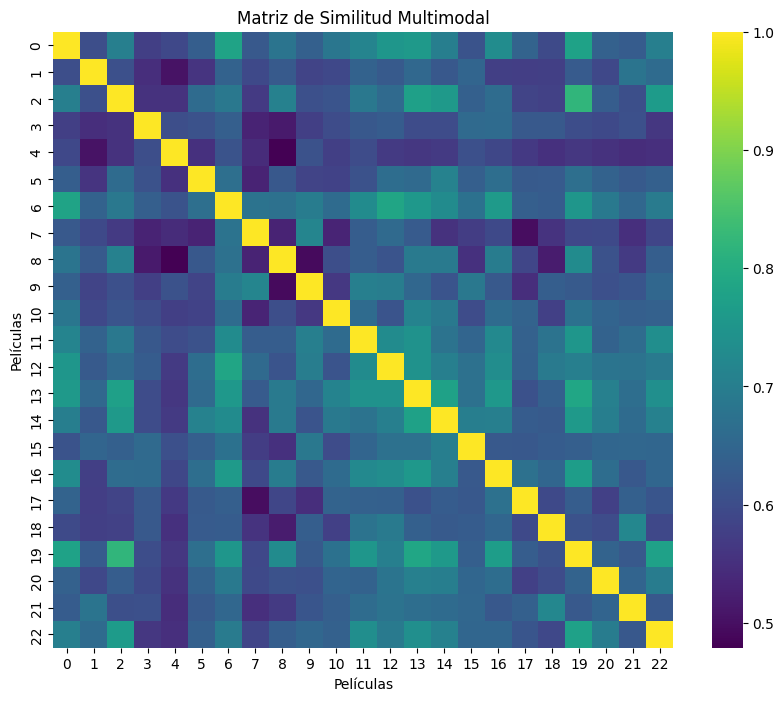

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    sim_multimodal,
    cmap="viridis"
)

plt.title(
    "Matriz de Similitud Multimodal"
)

plt.xlabel("Películas")
plt.ylabel("Películas")

plt.show()

Parte 12: t-SNE

In [29]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

emb_2d = tsne.fit_transform(
    combined_embeddings
)

print(emb_2d.shape)

(23, 2)


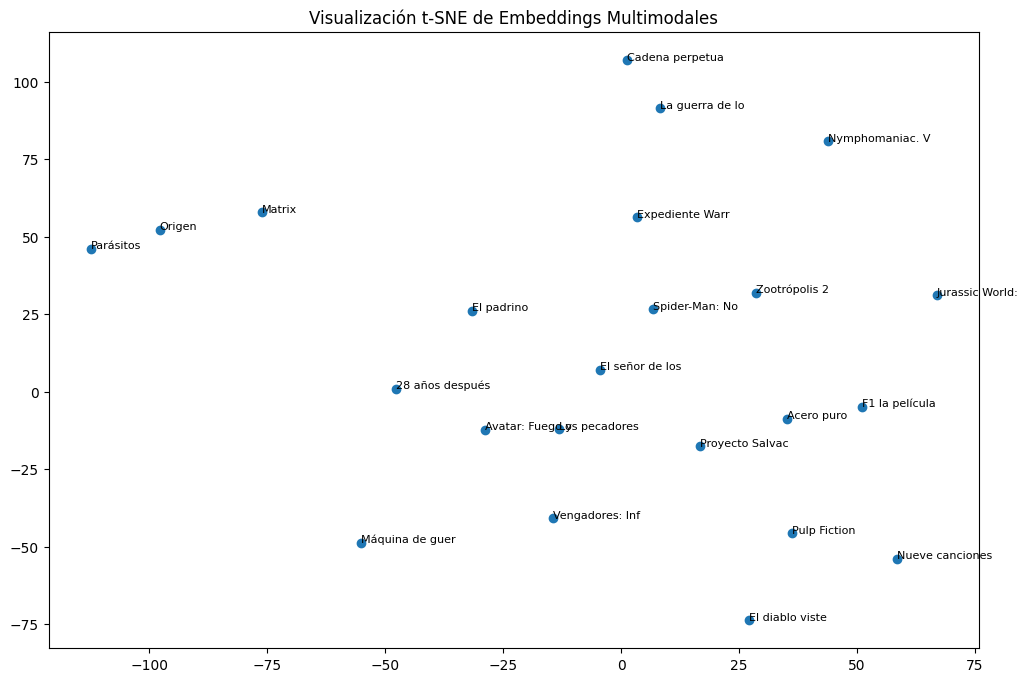

In [30]:
plt.figure(figsize=(12,8))

plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1]
)

for i, title in enumerate(titles):

    plt.annotate(
        title[:15],
        (
            emb_2d[i,0],
            emb_2d[i,1]
        ),
        fontsize=8
    )

plt.title(
    "Visualización t-SNE de Embeddings Multimodales"
)

plt.show()

Parte 4: Guardar resultados

In [31]:
np.save(
    "data/processed/multimodal_similarity.npy",
    sim_multimodal
)

print("Matriz de similitud guardada")

Matriz de similitud guardada
